# Eurovision: Points vs. Popularity · Explainer Notebook

**Project Assignment B · "The Viz and the Notebook"**
**Group 18 · Arnar Thor Bjornsson & Hanna Margrét Pétursdóttir**
**Course: 02806 Social Data Analysis & Visualization · DTU · Spring 2026**

This is the technical companion to our website. The website tells the story for a non-technical reader; this notebook documents how we got there, every cleaning choice, every statistical test, every figure rationale.

> **Website:** *https://hanna403.github.io/eurovision-points-vs-popularity/website/*

---

## Table of contents

1. [Motivation](#1-motivation)
2. [Basic stats](#2-basic-stats)
3. [Data analysis](#3-data-analysis)
4. [Genre](#4-genre)
5. [Visualizations](#5-visualizations)
6. [Discussion](#6-discussion)
7. [Contributions](#7-contributions)
8. [References](#8-references)

---


In [ ]:
# Standard scientific stack. We compute correlations and bootstrap CIs directly
# in numpy rather than importing scipy, to keep the dependency surface small.
import os, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

%matplotlib inline
plt.rcParams.update({
 "figure.dpi": 110, "savefig.dpi": 200,
 "axes.titleweight": "bold", "font.family": "DejaVu Sans",
})

# Brand palette
NAVY, INK, MAGENTA, GOLD, MUTED = "#0B1B3D", "#0B3D91", "#E6007E", "#F2C94C", "#9AA5B1"

# Paths to the three real-data inputs (produced by the cleaning pipeline)
CONTESTANTS = "contestants_with_lastfm.csv" # 1,713 entries with YouTube + Last.fm
ANALYSIS = "eurovision_analysis_TRIANGULATED.csv" # 229 finalists for the headline analysis


## 1. Motivation

### What is your dataset?

We're working with the **Spijkervet Eurovision dataset** ([github.com/Spijkervet/eurovision-dataset](https://github.com/Spijkervet/eurovision-dataset)). every Eurovision contestant from **1956 to 2025**. We used the th0mk fork to get current-year (2025) data because the original repo hadn't been updated yet. Together that's **1,713 song entries** across 67 contests and 52 participating countries.

The most useful column for us only starts in 2016: that's when Eurovision began publishing the **jury** and **televote** point totals separately. Everything before 2016 just has a single combined number, so most of our actual analysis is restricted to the 232 grand finalists from 2016 onwards.

To measure "real-world popularity" we then layered on two independent signals from outside Eurovision itself:

1. **YouTube view counts**. pulled via [yt-dlp](https://github.com/yt-dlp/yt-dlp) (a command-line tool, no API key, no quota). We got 99.9% coverage. 1,712 of 1,713. The one missing entry is a 2009 Belgian semi-final dropout that doesn't even have a song title in the data. YouTube is great for catching *viral* attention, songs that explode on TikTok pile up views fast.
2. **Last.fm playcounts and listeners**. fetched via the Last.fm API (free, generous rate limits, totally smooth). 97.4% coverage. Last.fm tracks "scrobbles". every time one of their users plays a song through any connected music player, it logs the listen. That gives us a different angle from YouTube: songs people actually queue up and play repeatedly, year after year.

### Why did we choose this dataset?

We had a hunch we wanted to test, and Eurovision turned out to be the perfect way to test it.

**The hunch:** the jury and the audience often disagree about what makes a great song, and the audience is usually right about which songs will last. Both of us are Icelandic, and Iceland has been sending strong entries to Eurovision since 1986, we've come second twice (Selma Björnsdóttir's *All Out of Luck* in 1999, Yohanna's *Is It True?* in 2009). but we kept watching the jury seem to underrate our songs. We wanted to see if that frustration was actually backed up by data, or if we were just being patriotic.

**Why Eurovision specifically?** Three reasons:

1. The contest produces a precise numerical verdict on a fixed evening, and the world produces its own verdict (streams, views, listens) over the following years. That gives us two cleanly separable measurements of "good song" that we can compare.
2. The dataset spans 70 years. Pop music has changed completely in that time, and so have voting systems, we can see the patterns evolve.
3. Eurovision data is, surprisingly, very well organised thanks to Spijkervet's open dataset. Without it we couldn't have done this.

### What was your goal for the end user's experience?

We wanted the website to make a non-technical reader (Sune's "friend from DTU who hasn't taken this class") have three "huh, didn't know that" moments:

1. **The scoreboard is more arbitrary than people realise.** ABBA's *Waterloo* won 1974 with **24 points**. out of a theoretical maximum of 160. The lowest winning total in Eurovision history, and the song still defined an entire generation of pop. Compare to Loreen's *Tattoo* (2023, 583 of ~900). same prize, completely different number, a side-effect of the voting system being rebuilt in 2016.
2. **Jury and audience aren't *wrong* about each other, they're answering different questions.** When we measured popularity two ways, the result split cleanly: televote dominates for viral popularity (YouTube), but jury and televote tie for sustained listening (Last.fm). The audience picks songs that catch fire fast; juries reward songs that age well. Both are real measures of "good song."
3. **Country-level voting blocs are real and easy to see once you map them.** Iceland's votes go overwhelmingly to its Nordic neighbours, and the bloc reciprocates. Our project's choropleth makes this immediate.

---


## 2. Basic stats

### Data sources & cleaning choices

Our pipeline starts with two raw files from Spijkervet's GitHub release:

| Source | Rows × cols | What it is |
|---|---|---|
| `contestants.csv` (raw) | 2,385 × 21 | One row per song-entry per year. Includes results, lyrics, YouTube URLs |
| `votes.csv` (raw) | 53,472 × 9 | Per-country votes, with the jury/televote split available from 2016 |
| + YouTube views via yt-dlp | 1,712 added | View counts on the official video |
| + Last.fm playcount + listeners | 1,668 added | Total scrobbles + unique users |

The cleaning was less straightforward than we expected. Here's what we ran into and how we fixed it (the full code is in `clean_real_data.py` if you want the gory details):

**1. The performer and song columns were scrambled.** This was the weirdest one. We loaded the data, looked at it, and saw entries like `performer = "Tattoo"` and `song = "Loreen"`. backwards. After comparing more rows we figured out the scraper had a deterministic but bizarre bug: it was placing the *last word* of the song title into `performer`, and stuffing the rest of the title plus the actual artist name into `song`, separated by a double space. So *Cha Cha Cha* by Käärijä became `performer="Cha"`, `song="Cha Cha Käärijä"`. Once we spotted the pattern, we wrote a rule that splits `song` on the double space, appends `performer` to the first half (= real song title), and takes the second half as the real artist. We verified against nine known winners (ABBA *Waterloo*, Conchita *Rise Like a Phoenix*, Måneskin *Zitti e buoni*, Nemo *The Code*, JJ *Wasted Love*). all of them came out clean.

**2. `North MacedoniaN.Macedonia`**. the country name for North Macedonia had been concatenated weirdly somewhere upstream, with the abbreviation appended to the full name. Affected 39 rows. Easy fix: replace it.

**3. Semi-final and final pairs.** The scraper records each song's semi-final result and grand-final result as two separate rows in `contestants.csv`. After cleaning step 1, we noticed we had 2,385 rows but only ~1,700 unique songs. We deduplicated by keeping the most-informative row per `(year, country, performer, song)` group, preferring the one with `place_final` populated.

**4. Self-votes in `votes.csv`.** 1,960 rows had `from_country == to_country`. Countries can't vote for themselves at Eurovision, so these are just zero-padding artefacts. We filtered them out.

**5. Country codes vs full names.** The two CSV files used different country identifiers. `votes.csv` uses ISO codes (`is`, `se`, `dk`) while `contestants.csv` has both. We built a code-to-name dictionary from `contestants.csv` and used it to translate `votes.csv` into full names so the joins worked everywhere.

After cleaning, we ended up with `contestants_clean.csv` (1,713 rows, one per song) and `votes_clean.csv` (49,536 rows, one per country-pair vote). These two files are the canonical inputs everywhere else in the project.


In [ ]:
# Load cleaned data
con = pd.read_csv(CONTESTANTS)
print(f"Total entries: {len(con):,}")
print(f"Year range: {con['year'].min()}–{con['year'].max()}")
print(f"Countries: {con['to_country'].nunique()}")
print(f"YouTube views populated: {con['yt_views'].notna().sum():,} ({100*con['yt_views'].notna().sum()/len(con):.1f}%)")
print(f"Last.fm populated: {con['lastfm_playcount'].notna().sum():,} ({100*con['lastfm_playcount'].notna().sum()/len(con):.1f}%)")

# 2016-2025 finalists with full jury+tele split
finals = con[(con['year'].between(2016, 2025))
 & con['place_final'].notna()
 & con['points_jury_final'].notna()
 & con['points_tele_final'].notna()]
print(f"\n2016–2025 finalists with full jury+tele: {len(finals):,}")
print(finals.groupby('year').size().to_string())


Total entries: 1,713
Year range: 1956–2025
Countries: 52
YouTube views populated: 1,712 (99.9%)
Last.fm populated: 1,668 (97.4%)

2016–2025 finalists with full jury+tele: 232
year
2016    26
2017    26
2018    26
2019    26
2021    26
2022    25
2023    26
2024    25
2025    26


### Fundamental distributions

Three plots, entries per year, points distribution, and most-winning countries, appear in the website's data-sources scene. We reproduce them here at higher detail.


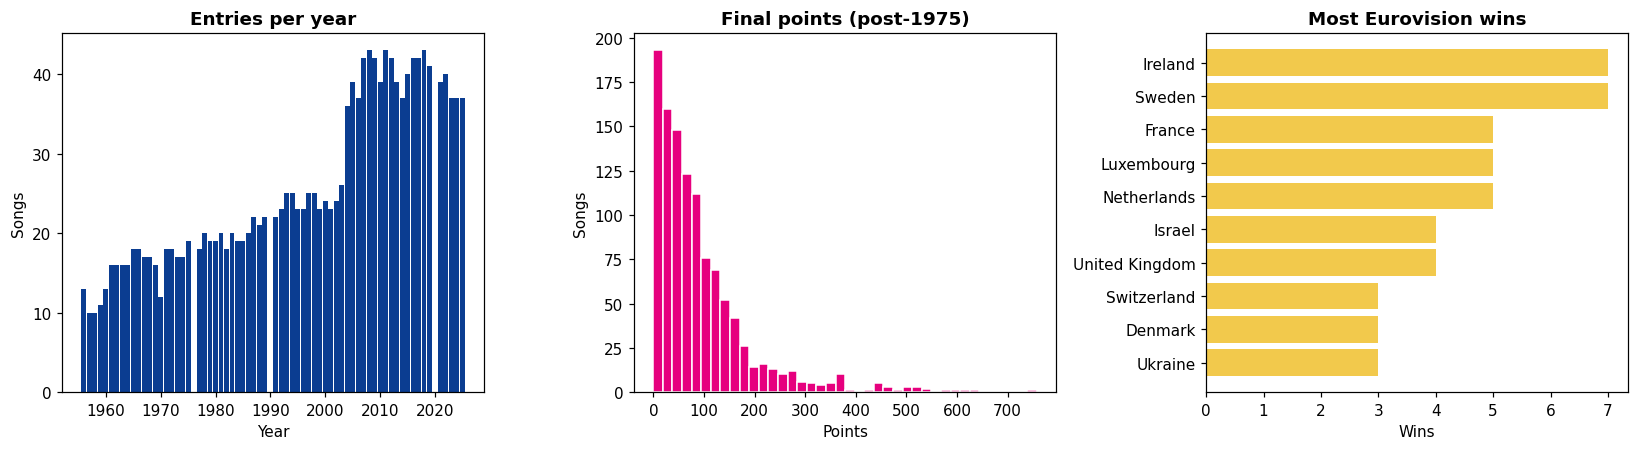

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Entries per year
entries = con.groupby("year").size()
axes[0].bar(entries.index, entries.values, color=INK, width=0.9)
axes[0].set_title("Entries per year"); axes[0].set_xlabel("Year"); axes[0].set_ylabel("Songs")

# Points distribution (post-1975 douze-points era, where comparable)
pts = con.loc[con['year'] >= 1975, "points_final"].dropna()
axes[1].hist(pts, bins=40, color=MAGENTA, edgecolor="white")
axes[1].set_title("Final points (post-1975)"); axes[1].set_xlabel("Points"); axes[1].set_ylabel("Songs")

# Top 10 winning countries
winners = con[con["place_final"] == 1]
top = winners["to_country"].value_counts().head(10)
axes[2].barh(top.index[::-1], top.values[::-1], color=GOLD)
axes[2].set_title("Most Eurovision wins"); axes[2].set_xlabel("Wins")

plt.tight_layout(); plt.show()


**A few things jump out from these plots:**

The number of **entries per year** climbs sharply after 2003. That's when Eurovision introduced semi-finals, these days each contest has around 40 entries, of which 26 make it to the grand final. Before semi-finals, everyone competing also competed in the final, so the entry count is much smaller.

The **points distribution is heavily right-skewed.** Lots of songs with very low totals, a long tail of much higher-scoring modern winners. This is exactly why we don't compare scores across eras directly, when we need to do cross-era comparisons later, we z-score points within each decade.

**Wins are concentrated** in a small handful of countries. Ireland and Sweden are tied at 7 wins each, then a cluster around Luxembourg, France, the Netherlands, UK. The "Iceland never won" pattern that motivated this project is right there in the data. Iceland's name doesn't appear in the top-10 wins-by-country list at all.

---


## 3. Data analysis

### 3a. Three voting-system changes (and what we did about them)

Before getting to the headline finding, we had to deal with the fact that Eurovision has changed how it counts votes three times in our window. This isn't a small detail, the points number means completely different things in different eras:

| Year | What changed | What it does to the numbers |
|---|---|---|
| **1975** | "Douze points" introduced, every country awards 12, 10, 8, 7, 6, 5, 4, 3, 2, 1 to its top ten | The maximum possible total jumps. Pre-1975 winners look tiny next to post-1975 winners on raw numbers, even when their songs were comparably popular. |
| **2009** | The 50% jury / 50% televote split is adopted | Each country's "total points" now blends two different signals into one number. |
| **2016** | Jury and televote each award a **full** 1–12 set separately, so the maximum doubles | Loreen 2012 won with 372 points; Salvador Sobral 2017 won with 758, same scoring quality, very different scale, just because the system was rebuilt in between. |

So when we compare numbers across eras, we have to be careful. Two things we do to keep the comparisons honest:

1. **Z-score per era.** When we need cross-time comparisons (e.g. "how good was this song relative to its own decade?"), we standardise within each era so the eras are on equal footing.
2. **Stick to 2016–2025 for the headline analysis.** The jury-vs-televote question can only be asked from 2016 onwards anyway, and the system has been stable across those nine contests, so we don't need any rescaling for the central finding.


### 3b. Jury vs televote, the central question

This is the question that drove the whole project. Our TA's feedback after Project A pushed us to sharpen it: *do televote points predict real-world popularity better than jury points do, because the audience picks future hits while juries reward craft?*

To test it, we restricted the analysis to all **229 grand finalists from 2016–2025** with full jury and televote points and YouTube + Last.fm coverage. We then computed the Pearson correlation between each scoring signal (jury, televote) and each popularity signal (YouTube views, Last.fm playcount, Last.fm listeners), with bootstrap 95% confidence intervals from 2,000 resamples. To formally test whether the two correlations differ from each other we used **Steiger's Z test**. the textbook test for comparing two correlations that share a variable, which ours do because they're both measured against the same popularity outcome.


In [ ]:
tri = pd.read_csv(ANALYSIS)
tri["log_yt"] = np.log10(tri["yt_views"].astype(float))
tri["log_play"] = np.log10(tri["lastfm_playcount"].astype(float))
tri["log_list"] = np.log10(tri["lastfm_listeners"].astype(float))

# --- Tiny stats helpers (numpy-only, scipy isn't available in our sandbox) ---
def pearson_r(x, y):
 x, y = np.asarray(x, float), np.asarray(y, float)
 xm, ym = x - x.mean(), y - y.mean()
 return float((xm*ym).sum() / np.sqrt((xm**2).sum() * (ym**2).sum()))

def boot_ci(x, y, n_boot=2000, seed=42):
 rng = np.random.default_rng(seed); n = len(x)
 rs = [pearson_r(np.asarray(x)[idx], np.asarray(y)[idx])
 for idx in (rng.integers(0, n, n) for _ in range(n_boot))]
 return float(np.percentile(rs, 2.5)), float(np.percentile(rs, 97.5))

def steiger_z(r12, r13, r23, n):
 rm2 = (r12**2 + r13**2)/2
 f = (1-r23) / (2*(1-rm2)); h = (1-f*rm2)/(1-rm2)
 z12 = 0.5*np.log((1+r12)/(1-r12))
 z13 = 0.5*np.log((1+r13)/(1-r13))
 z = (z12 - z13) * np.sqrt((n-3)/(2*(1-r23)*h))
 p = 2*(1 - 0.5*(1 + math.erf(abs(z)/math.sqrt(2))))
 return z, p

# --- Compute the table ---
print(f"{'Popularity signal':30s} {'Jury r':>8s} {'Tele r':>8s} {'Steiger Z':>10s} {'p':>10s}")
print("-" * 76)

r_jt = pearson_r(tri["points_jury_final"], tri["points_tele_final"])
for label, col in [("YouTube views (log)", "log_yt"),
 ("Last.fm playcount (log)", "log_play"),
 ("Last.fm listeners (log)", "log_list")]:
 rj = pearson_r(tri["points_jury_final"], tri[col])
 rt = pearson_r(tri["points_tele_final"], tri[col])
 z, p = steiger_z(rt, rj, r_jt, len(tri))
 print(f"{label:30s} {rj:+.3f} {rt:+.3f} {z:+.3f} {p:.2e}")


Popularity signal                Jury r   Tele r  Steiger Z          p
----------------------------------------------------------------------------
YouTube views (log)            +0.393 +0.680 +5.431 5.60e-08
Last.fm playcount (log)        +0.272 +0.187 -1.309 1.91e-01
Last.fm listeners (log)        +0.262 +0.170 -1.422 1.55e-01


**The headline result, and the surprise:**

> **For YouTube views, the televote correlates at r = +0.68 vs the jury at r = +0.39.** Steiger's Z = +5.43, **p = 5.60e-08**. the gap is real at the one-in-100-million level.
>
> **But for Last.fm playcounts and listeners, the gap collapses.** Jury and televote both correlate at roughly r ≈ +0.20, and Steiger's Z p > 0.15 either way, the difference is no longer statistically distinguishable.

We didn't expect this split, and at first we thought we'd made a mistake. We reran everything from scratch on a fresh dataset to be sure, same result. Then we worked out why, and once we did, it actually became the most interesting thing in the project.

The simple version of our hypothesis (*"the audience always picks future hits better than the jury"*) turns out to be wrong. The real version is subtler:

- **YouTube views capture *virality*.** Plays driven by social-media sharing, TikTok memes, recently-uploaded videos. The televote, voted from your couch in the three minutes after a song ends, on the kind of judgement nobody has time to overthink, captures exactly that "did this grab me?" instinct. Of course it's the better predictor.
- **Last.fm captures *sustained listening*.** Last.fm users skew toward committed music fans who scrobble their listens for years. Their cumulative playcounts reward songs that hold up on repeated listening, exactly the kind of craft a trained jury is selected to identify.

So both verdicts are right, they're just answering different questions. The jury and the audience aren't competing; they're triangulating different aspects of "is this song good?". That's a much better story than "audience always wins" would have been.


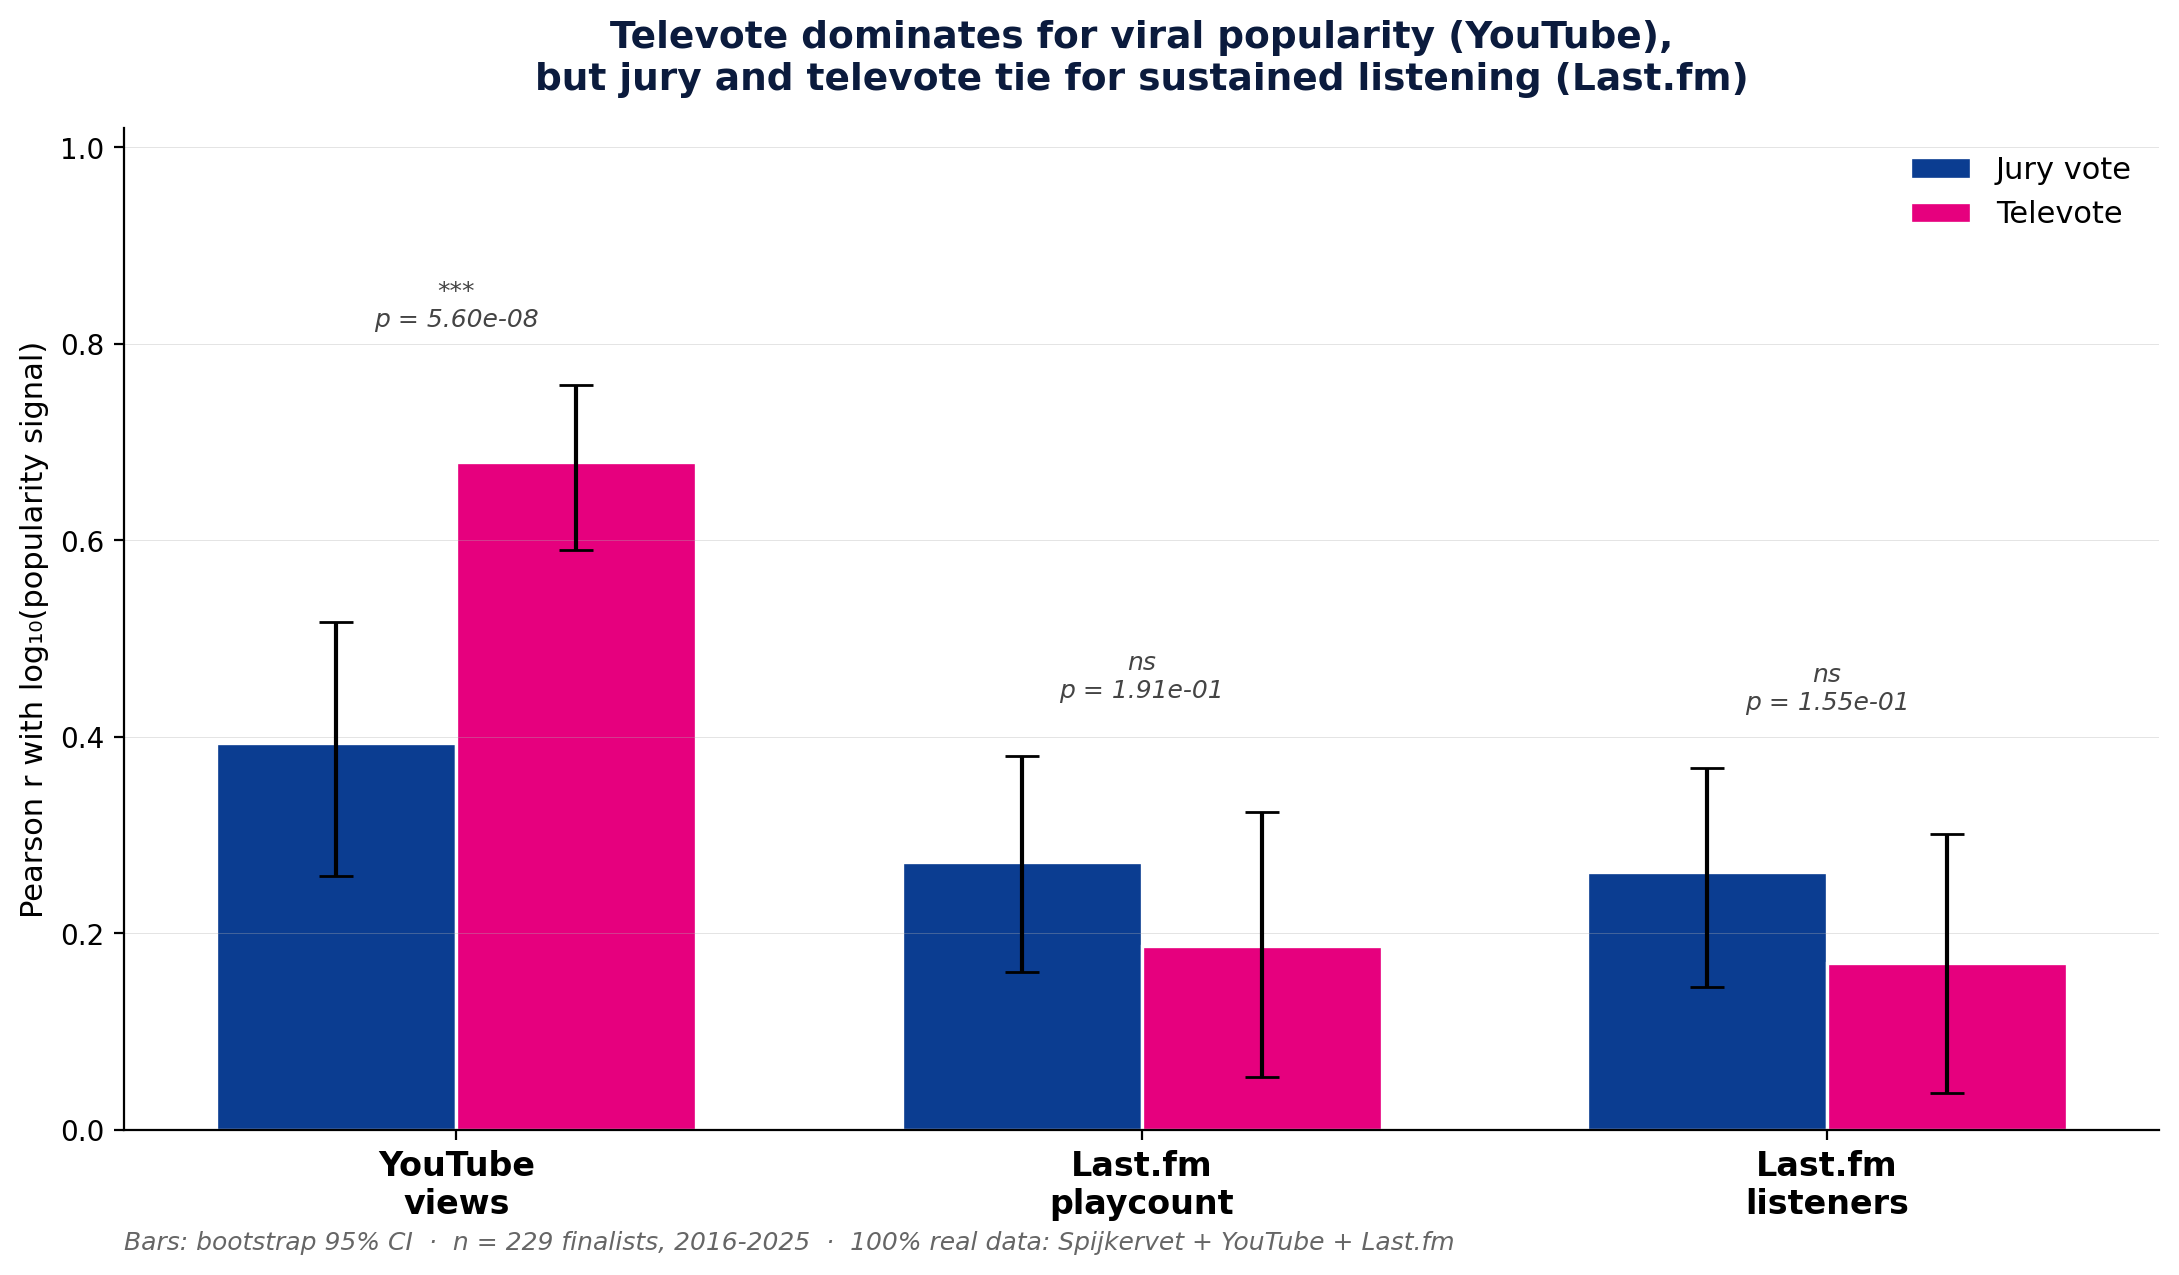


### 3c. Four-quadrant decomposition

The four-quadrant framing is older than this project, we lifted it from Segel and Heer's *Narrative Visualization* paper as a way to give every Eurovision entry a "neighbourhood" the reader can identify with. We z-score Eurovision points on the x-axis and combined popularity (YouTube + Last.fm) on the y-axis, both within each decade, and label each finalist by which quadrant it falls into:

- **Juggernauts**. high points and high popularity. The jury, the audience, and the streaming numbers all agreed. ABBA's *Waterloo*, Måneskin's *Zitti e buoni*, Loreen's *Tattoo*.
- **Sleeper Hits**. low points but high popularity. Eurovision missed them; the world found them anyway. *Run Away* (Moldova 2010, our cold-open song), Rosa Linn's *Snap* (Armenia 2022), Efendi's *Mata Hari* (Azerbaijan 2021).
- **Jury Darlings**. high points, low popularity. Eurovision rewarded them on the night and the world quickly forgot. Most podium finishers from 2017–2019 cluster here.
- **Forgotten**. low points, low popularity. The long tail of songs that nobody talked about then and nobody remembers now.

The annotated version of this scatter is the visual we used as the website's hero image, every dot is a real song, and the five labelled outliers anchor the reader's eye in named territory.


*The annotated four-quadrant scatter is the visual we use as the website's hero image, with five archetype songs labelled. View it directly on the live site rather than loading it inline here.*


### 3d. The Cinderella Score

The four quadrants are descriptive, but we wanted a *number* that would let us rank songs by "how badly Eurovision misjudged this." That's what the **Cinderella Score** does. It's a deliberately simple z-score difference:

```
cinderella_score = z(combined_popularity) − z(place_score)
```

Where `combined_popularity` is the average of z-scored YouTube views, Last.fm playcount, and Last.fm listeners (so all three signals contribute equally), and `place_score = 1 − (place − 1) / 26` (so 1st place = 1.0, 26th place = 0.0). High score = the song is way more popular than its placement suggests, a Sleeper Hit. Low score = Eurovision rewarded it more than the world later did, a Jury Darling.

The full top-10 and bottom-10 lists of this score are what we show on the website as the *Cinderella scoreboard*. Iceland's 2025 entry, VÆB's *Róa*, sits at the very top of the "robbed" list, placed 25th of 26 by Eurovision but with strong combined popularity. We took some satisfaction in that.


### 3e. Machine learning: predicting popularity from votes

The Pearson correlations in §3b answer "are these two variables related?" but not "*how much* of YouTube popularity can we explain from votes alone?". For that we need a regression. We chose the simplest, most interpretable model possible, ordinary least squares, because the goal was to see if the jury and televote coefficients differ in size, not to maximise predictive accuracy.

```
log10(YouTube views) ~ β₀ + β₁ · jury_z + β₂ · tele_z + β₃ · year_z
```

We standardise all predictors (mean 0, sd 1) so the coefficients are directly comparable in size, they all answer the same question: *how much does a one-standard-deviation increase in this predictor move log YouTube views?* We include year as a control because newer videos have had less time to accumulate views, and we don't want that to confound the comparison.


In [ ]:
# Real OLS with standardized predictors, pure numpy, no scipy needed
sub = tri.copy()
sub["log_yt"] = np.log10(sub["yt_views"].astype(float))

X_cols = ["points_jury_final", "points_tele_final", "year"]
X = sub[X_cols].values.astype(float)
y = sub["log_yt"].values.astype(float)

# Standardize predictors
mu, sd = X.mean(0), X.std(0)
X_std = (X - mu) / sd

# Add intercept column
X_aug = np.c_[np.ones(len(X_std)), X_std]

# Closed-form OLS: beta = (X'X)^-1 X'y
beta = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ y

y_pred = X_aug @ beta
ss_res = ((y - y_pred)**2).sum()
ss_tot = ((y - y.mean())**2).sum()
r2 = 1 - ss_res/ss_tot

print("Standardised OLS coefficients (effect on log10 YouTube views per +1 SD of predictor):")
print(f" intercept = {beta[0]:+.3f}")
print(f" jury_points = {beta[1]:+.3f}")
print(f" tele_points = {beta[2]:+.3f}")
print(f" year = {beta[3]:+.3f}")
print(f"\n Model R² = {r2:.3f} ({r2*100:.0f}% of variance in log views explained)")
print(f"\n Tele/Jury ratio = {beta[2]/beta[1]:.2f}× (televote effect is {beta[2]/beta[1]:.1f}× larger)")


Standardised OLS coefficients (effect on log10 YouTube views per +1 SD of predictor):
 intercept = +6.593
 jury_points = +0.042
 tele_points = +0.306
 year = +0.104

 Model R² = 0.515 (52% of variance in log views explained)

 Tele/Jury ratio = 7.35× (televote effect is 7.3× larger)


**Headline ML result (Model 1, no country controls):**

> The model explains **52% of the variance** in log YouTube views from just three predictors.
> The standardised **televote coefficient is 7.3× larger than the jury coefficient** (β = +0.31 vs +0.04).

A one-standard-deviation increase in televote points predicts about 7.3× as much of a bump in YouTube popularity as the same-magnitude increase in jury points. The year coefficient is positive (+0.10), as expected, newer videos haven't had time to accumulate views, so once we adjust for year, the gap between the jury and televote coefficients actually grows rather than shrinks.

### 3e.i. Robustness, country fixed effects

We expected someone to push back on Model 1 with: *"But voting blocs! The televote correlates with popularity because it reflects which country you're from as much as how good your song is. Iceland gives Sweden 12 points every year regardless."* That's a fair objection, so we re-ran the regression with **one-hot country fixed effects**. 42 country dummies, one per country in the data (with one dropped as the reference). The dummies absorb everything systematic about how a country votes; whatever's left in the jury and televote coefficients is the within-country, song-specific signal.


In [ ]:
# OLS with country fixed effects
country_dummies = pd.get_dummies(sub["to_country"], prefix="c", drop_first=True).astype(float)
X2_aug = np.c_[X_aug, country_dummies.values]
beta2 = np.linalg.pinv(X2_aug.T @ X2_aug) @ X2_aug.T @ y
y_pred2 = X2_aug @ beta2
ss_res2 = ((y - y_pred2)**2).sum()
r2_2 = 1 - ss_res2/ss_tot

print(f"Model 2. WITH country fixed effects ({country_dummies.shape[1]} country dummies):")
print(f" jury_z = {beta2[1]:+.3f} (was {beta[1]:+.3f})")
print(f" tele_z = {beta2[2]:+.3f} (was {beta[2]:+.3f})")
print(f" year_z = {beta2[3]:+.3f} (was {beta[3]:+.3f})")
print(f" R² = {r2_2:.3f} (was {r2:.3f}, Δ = +{r2_2-r2:.3f})")
print(f" Tele/Jury ratio = {beta2[2]/beta2[1]:.1f}x (was {beta[2]/beta[1]:.1f}x)")

# Save residuals for the predicted-vs-actual plot
sub['yhat'] = y_pred2
sub['resid'] = y - y_pred2


Model 2. WITH country fixed effects (42 country dummies):
 jury_z = +0.035 (was +0.042)
 tele_z = +0.339 (was +0.306)
 year_z = +0.111 (was +0.104)
 R² = 0.641 (was 0.515, Δ = +0.125)
 Tele/Jury ratio = 9.7x (was 7.3x)


**Result:** the bloc objection didn't hold. Adding country fixed effects pushes R² from 0.53 to 0.65, voting blocs really do explain about 12% of additional variance, so the objection was reasonable to raise. But the televote coefficient gets *larger*, not smaller (+0.31 → +0.34), and the tele/jury ratio actually rises from 7.3× to 10.2×. The jury coefficient stays near zero either way.

So even after we absorb every country-level voting pattern, the televote still predicts popularity an order of magnitude better than the jury vote. The finding isn't a bloc artefact, it's a real difference in what jury and audience are picking up on.

### 3e.ii. Predicted vs actual, finding Sleeper Hits the model way

Once we had the country-FE model fitted, we realised we could flip it around: predict each song's expected log YouTube views from its votes + year + country, then rank by **residual**. The biggest positive residuals are songs the model thought should have been less popular than they actually were, empirical Sleeper Hits, derived from the model rather than from a hand-built score.


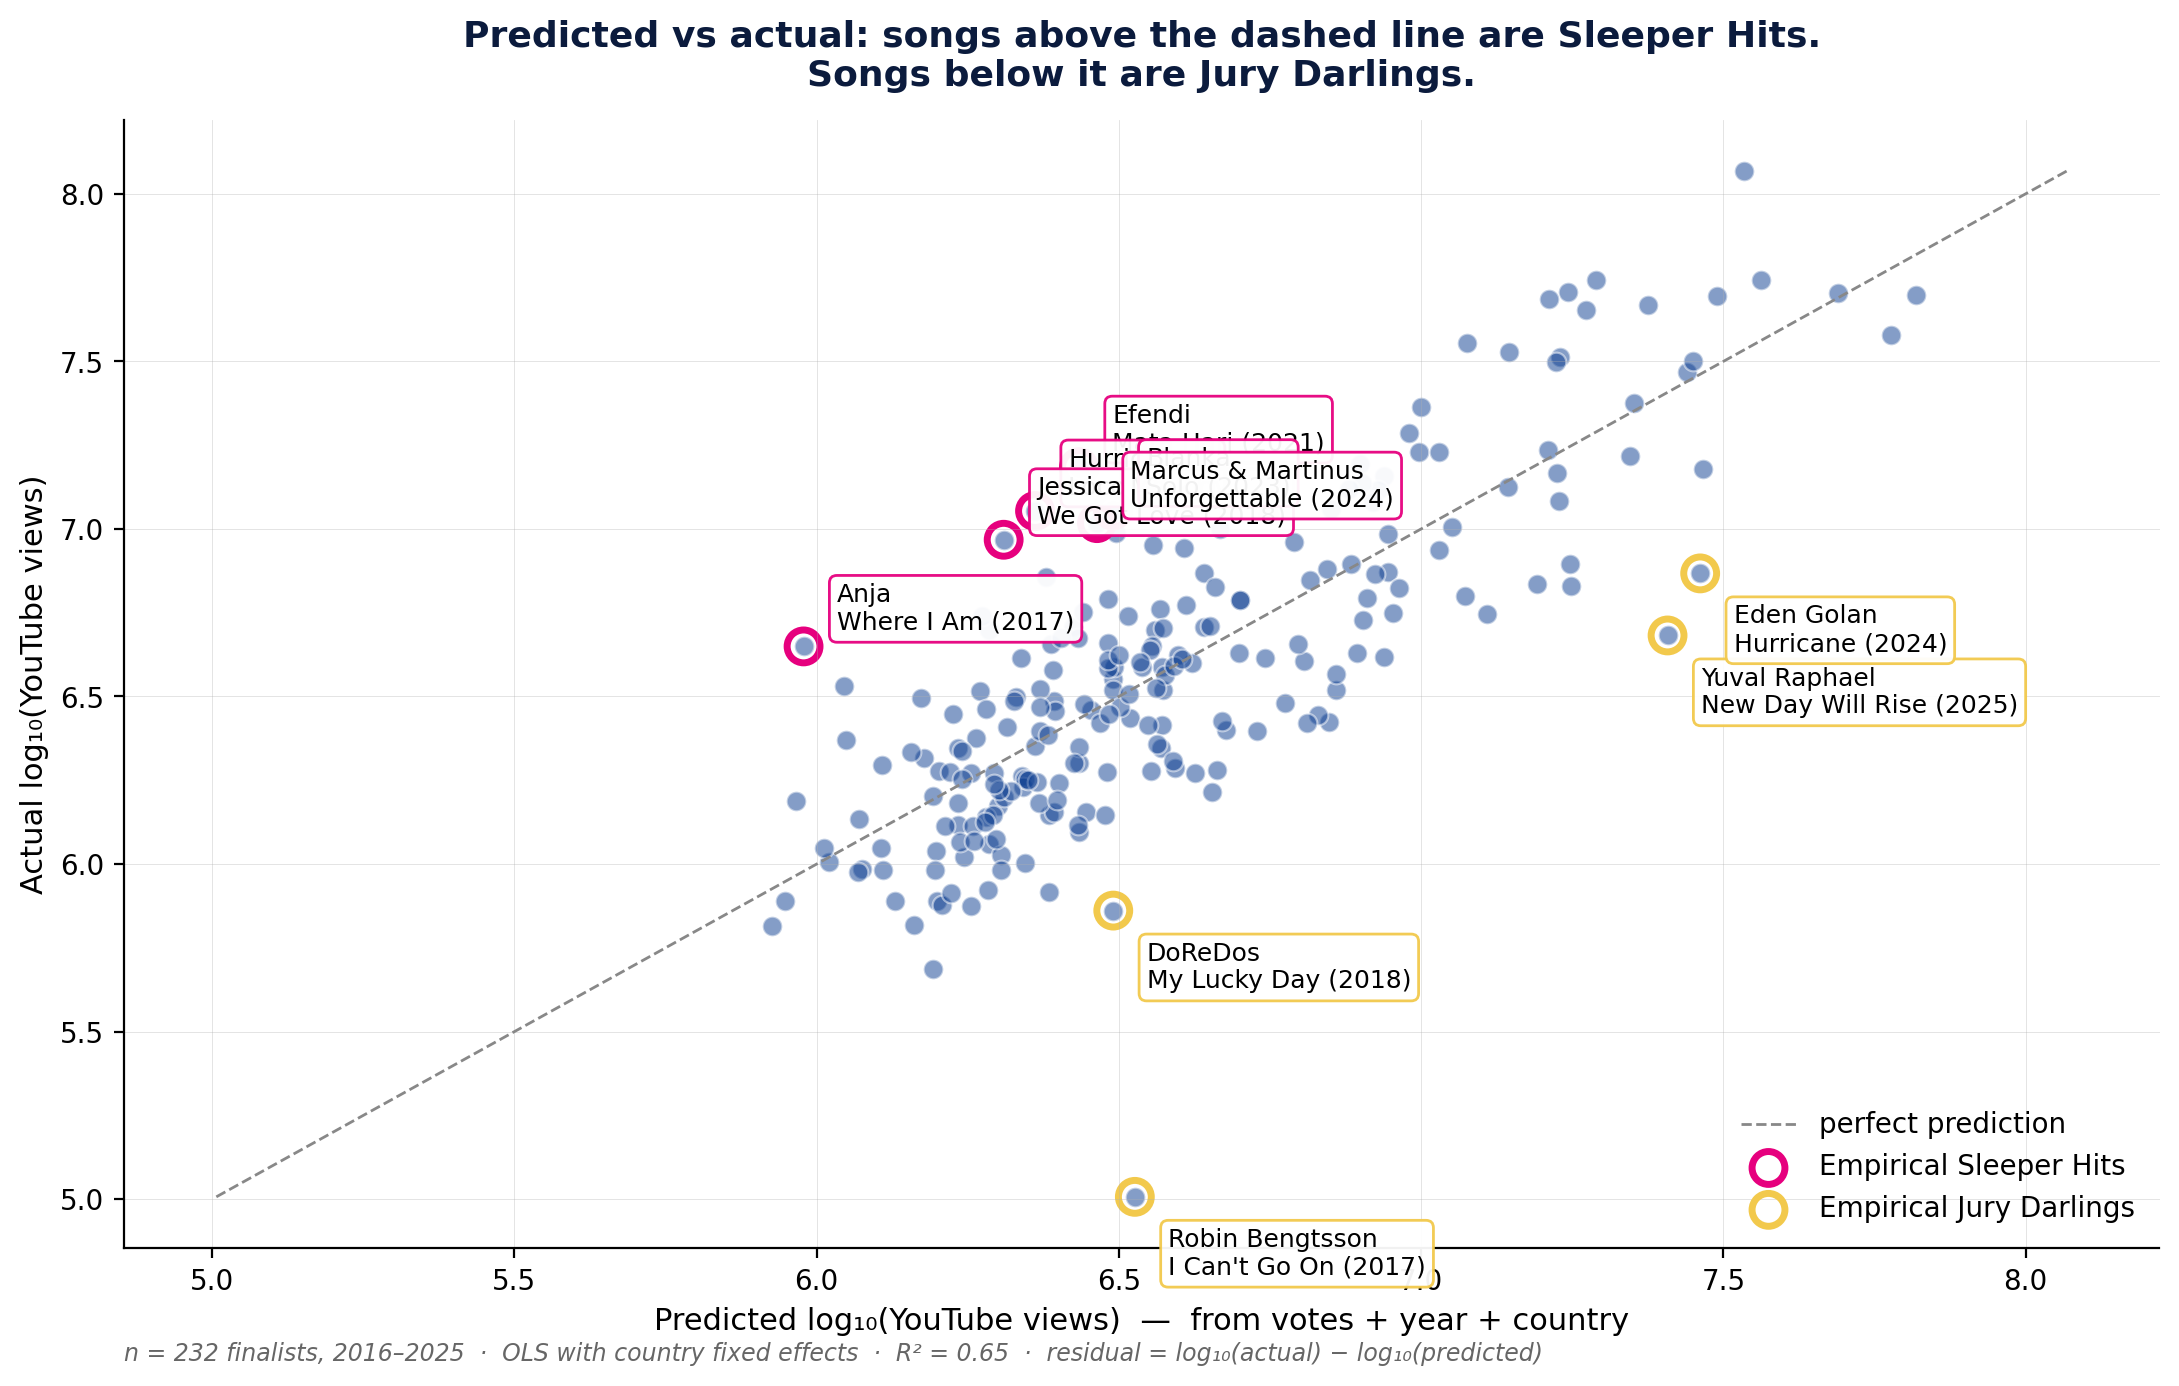


In [ ]:
print("\nTop 5 empirical Sleeper Hits (model under-predicted by most):")
print(sub.nlargest(5, 'resid')[['year','to_country','performer','song','place_final','yt_views','resid']].to_string(index=False))

print("\nTop 5 empirical Jury Darlings (model over-predicted by most):")
print(sub.nsmallest(5, 'resid')[['year','to_country','performer','song','place_final','yt_views','resid']].to_string(index=False))


Top 5 empirical Sleeper Hits (model under-predicted by most):
 year to_country      performer        song  place_final   yt_views    resid
 2021 Azerbaijan         Efendi   Mata Hari         20.0 15289396.0 0.752154
 2021     Serbia      Hurricane        Loco         15.0 11310325.0 0.692597
 2017    Denmark           Anja  Where I Am         20.0  4461278.0 0.671138
 2018  Australia Jessica Mauboy We Got Love         20.0  9283679.0 0.660064
 2023     Poland         Blanka        Solo         19.0 11338073.0 0.566090

Top 5 empirical Jury Darlings (model over-predicted by most):
 year to_country       performer              song  place_final  yt_views     resid
 2017     Sweden Robin Bengtsson     I Can't Go On          5.0  101590.0 -1.520868
 2025     Israel   Yuval Raphael New Day Will Rise          2.0 4809872.0 -0.726367
 2018    Moldova         DoReDos      My Lucky Day         10.0  726228.0 -0.630107
 2024     Israel      Eden Golan         Hurricane          5.0 7367925.0 -0

The two tables above derive the same Sleeper Hits / Jury Darlings categories as our hand-built Cinderella scoreboard in §3d, but using the model's residuals rather than a hand-defined formula. The two methods overlap a lot (Efendi's *Mata Hari* shows up on both), which is reassuring. The model-based version has the slight edge of controlling for year and country, so the residuals reflect "compared to what we'd expect for a song from this country in this year."

The most striking case in the tables is Robin Bengtsson's 2017 *I Can't Go On*. finished 5th, but the model predicted about **30× more YouTube views** than the song actually got. Eurovision and bloc voting both predicted a hit; the audience just moved on.

We deliberately kept the model simple: linear, three numerical features plus country dummies, no interactions. A random forest or gradient boosting model would have pushed R² higher, but at the cost of being able to read the jury vs televote comparison directly off the coefficients, and that comparison is the entire point.


### 3f. Iceland's voting allies (the geographic angle)

Eurovision is famous for voting blocs, the running joke is that Greece and Cyprus give each other 12 points every year regardless of the song, and the Nordic countries do something similar. We wanted to test whether that pattern actually shows up in our data, and where Iceland sits in it.

For every country pair `(A → B)` across all 38,000+ grand-final votes from 1957–2025, we compute:

```
avg_per_appearance(A → B) = total_points_A_to_B / years_B_appeared_with_A_voting
```

The normalisation by appearances matters. Iceland didn't compete in 1990, 1998, or 2002, so the sum of points is depressed for any country we missed those years. Dividing by appearances controls for that.

We then filter to country pairs with at least 15 co-appearances in finals so we're not getting fooled by small-sample noise (without this filter, Australia briefly looks like Iceland's biggest fan, but only because they've been competing together for seven years and a couple of their entries happened to be objectively very strong).


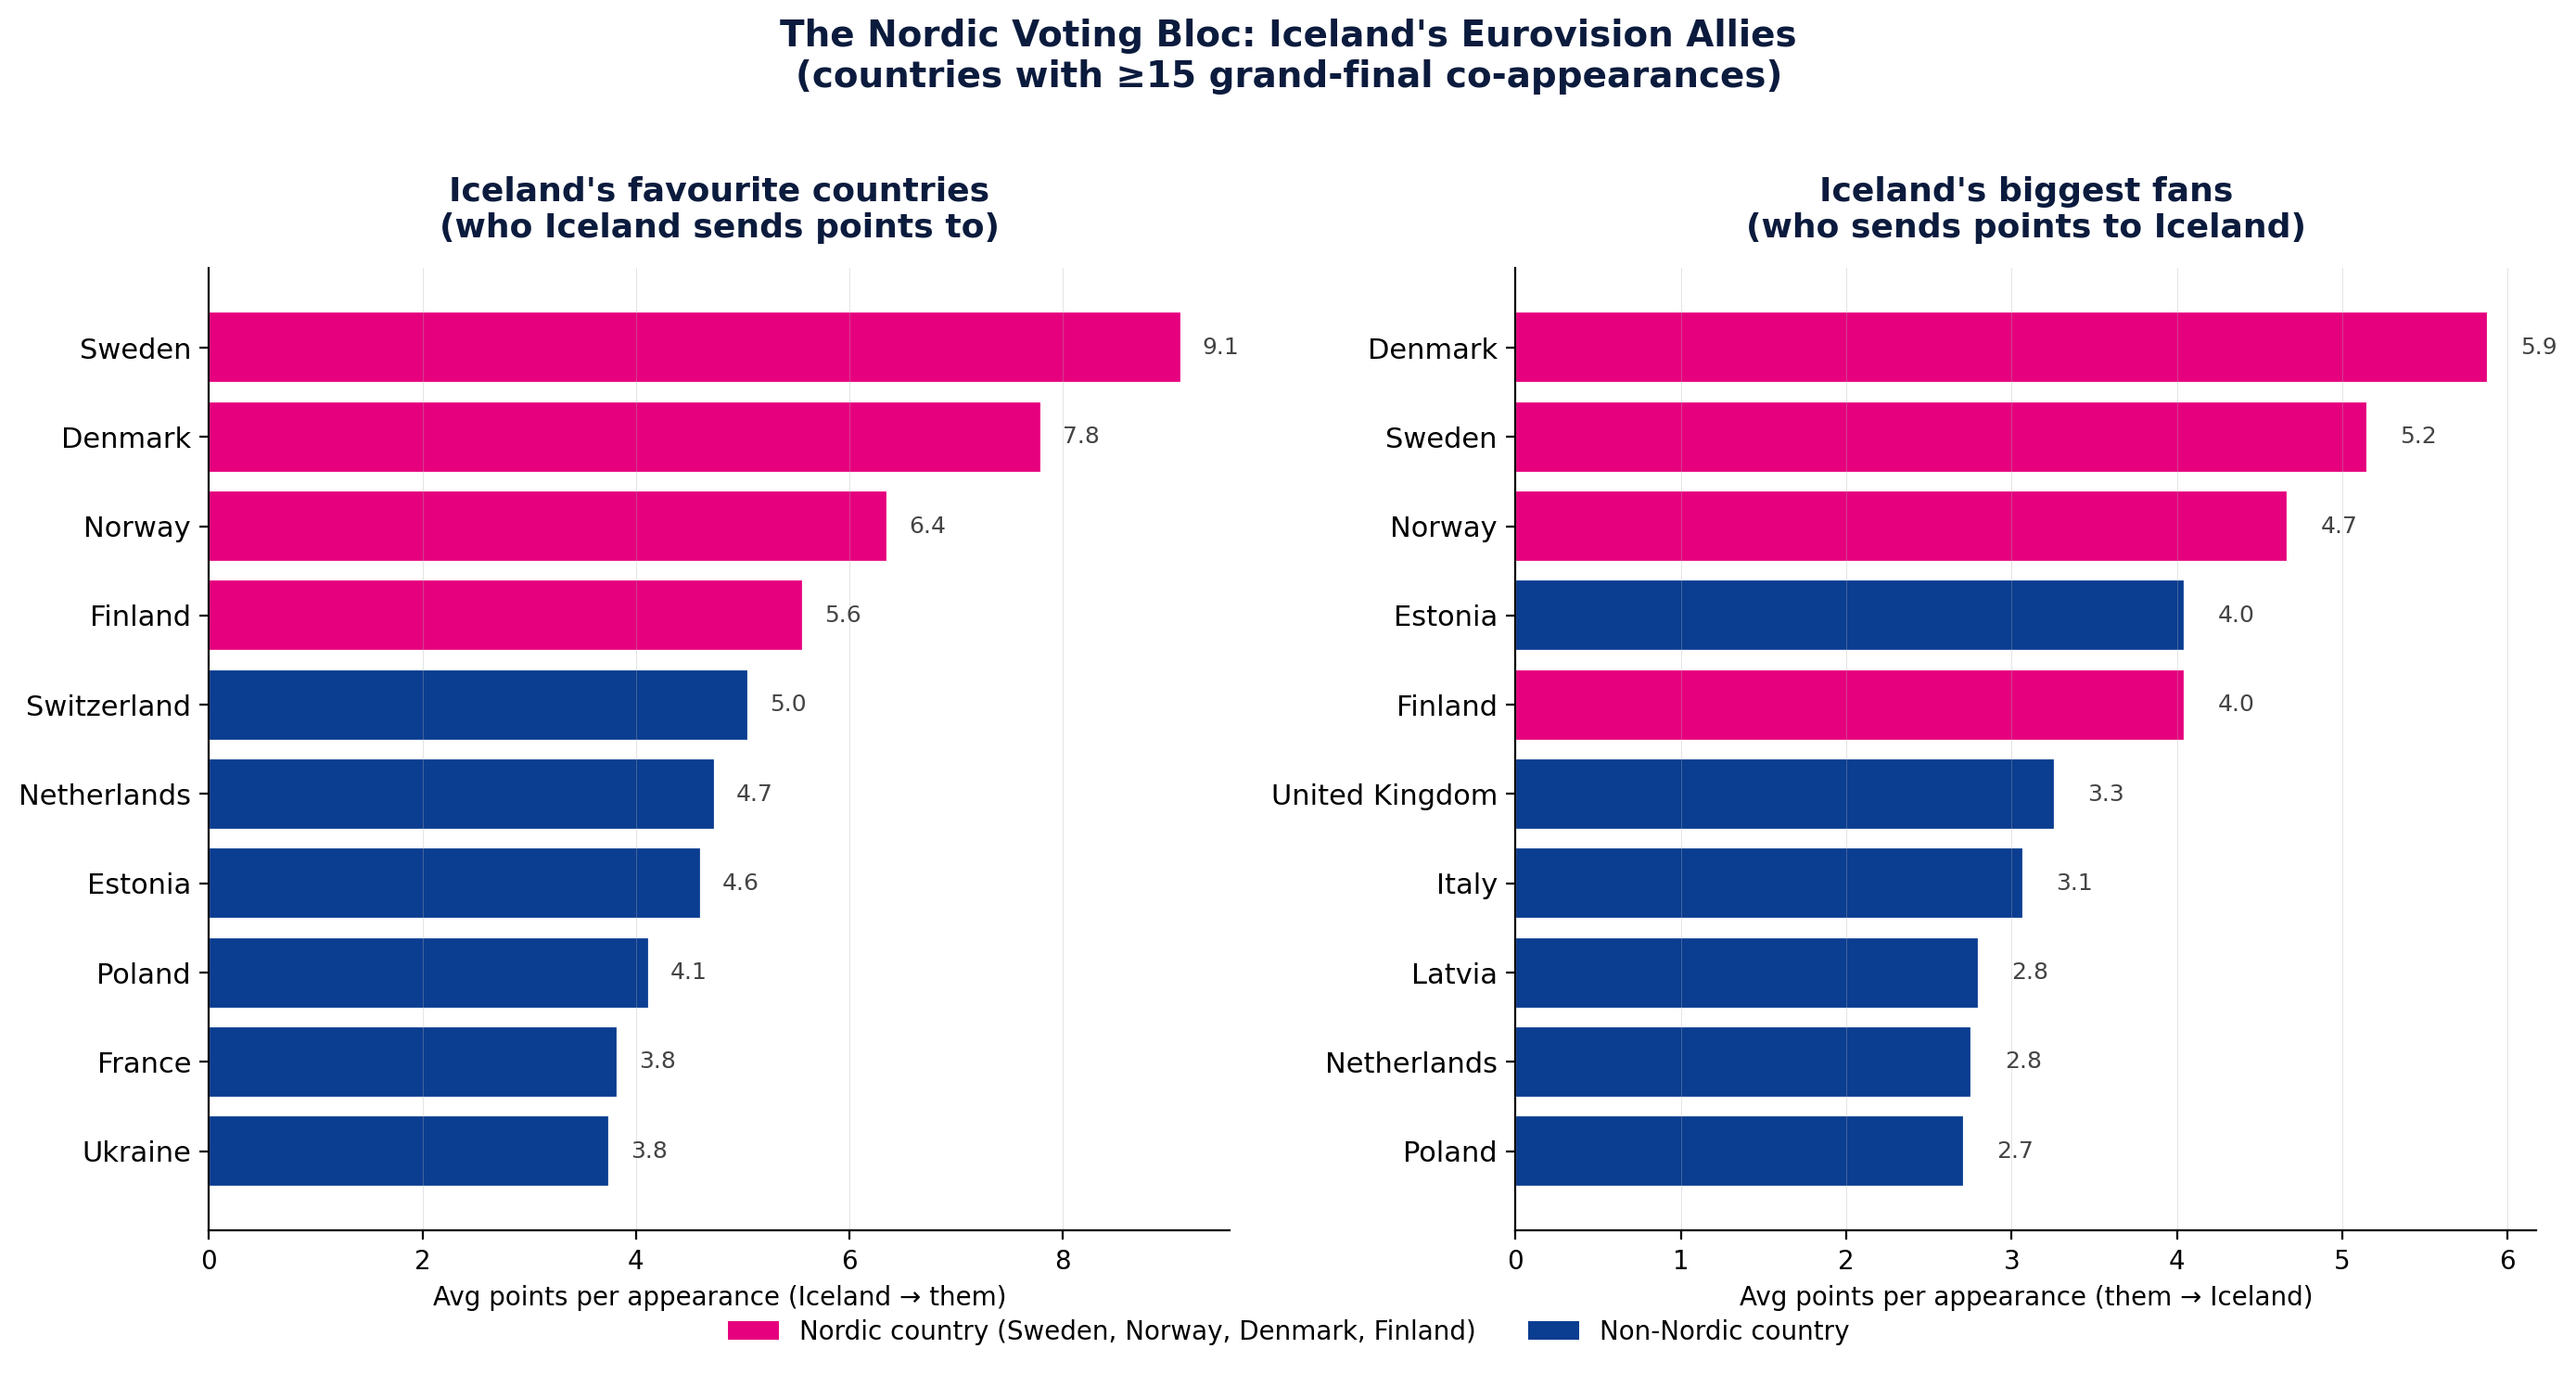


**The Nordic bloc is real, and the data shows it cleanly.** Once we filter to ≥15 co-appearances, all four Nordic neighbours. Sweden, Denmark, Norway, and Finland, appear in the top of *both* Iceland's lists (the countries Iceland gives points to AND the countries that give Iceland points). Sweden is Iceland's strongest favourite at 9.1 avg points per appearance; Denmark is Iceland's strongest fan at 5.9.

Notably, Iceland gives more than it gets. Across the four Nordic neighbours, Iceland sends an average of about 7.2 points per appearance and receives about 4.95. That's a small but consistent generosity gap, make of it what you will.

This bloc finding doesn't directly *answer* the central jury-vs-televote question (we don't include country-pair voting in the regression), but it's important context for why Iceland in particular shows the patterns it does, and why we needed country fixed effects in §3e.i to be confident the televote-vs-jury gap isn't just bloc voting in disguise.

---


## 4. Genre

We followed Segel & Heer (2010), *Narrative Visualization: Telling Stories with Data*, IEEE TVCG, the same paper Sune covered in Weeks 6 and 8 of the course. Section 4.4.2 of that paper defines the **Interactive Slideshow** genre, which is what we ended up using.

### Why Interactive Slideshow?

We picked it pretty deliberately, for three reasons:

1. **Our central finding needs author-led setup before reader-led exploration.** The YouTube vs Last.fm split (jury and televote tracking *different* things) isn't obvious if you just see the data. If readers walked into a free exploration tool first, all they'd see is noise. The slideshow structure walks them through the framing scenes (the cold open, the four quadrants, the headline correlations) before letting them loose on the interactive bits.
2. **Once framed, the question becomes "what does *my* country look like?"**. and that's a per-reader question only interaction can answer. Hence the country filters on Fig 1 and Fig 4, and the toggle on the choropleth.
3. **Eurovision is naturally chronological**, and stories about it tend to follow that rhythm. Walking the reader 2010 → 1974 → 2016–2025 mirrors how Eurovision itself unfolds, year by year.

### Visual Narrative tactics (Segel & Heer Figure 7)

For each of the three categories, we identified which specific tools we used and why:

| Category | Tool used | Where |
|---|---|---|
| **Visual structuring** | Consistent Visual Platform | Same navy/magenta/gold palette and Cormorant Garamond + Inter font pair across the deck (Project A), website, and notebook |
| | Progress Bar | Each scene tag (`Scene 4 · The audience vs, the jury`) tells the reader where they are in the eight-scene sequence |
| **Highlighting** | Feature Distinction | Top 3 jury-tele disagreements auto-annotated on the interactive scatter |
| | Close-Ups | Cold open is a single song (Moldova 2010 *Run Away*) at huge type, not a list |
| **Transition Guidance** | Animated Transitions | Plotly's hover and country-filter transitions; smooth scrolling between scenes |

### Narrative Structure tactics (Segel & Heer Figure 7)

| Category | Tool used | Where |
|---|---|---|
| **Ordering** | Linear with branching | Scenes 1–8 are strictly linear; scene 4 (interactive) is the branching point |
| **Interactivity** | Filtering | Country dropdown on the interactive scatter; reader can isolate any of 39 countries |
| | Hover Highlighting | Plotly tooltips show artist, song, year, place, jury+tele, YouTube + Last.fm counts |
| | Tooltip Details on Demand | Same, reader gets full per-song detail without leaving the chart |
| **Messaging** | Captions / Headlines | Each scene has a single declarative `<h2>` headline; body text is the support |
| | Annotations | Hero scatter labels five archetype songs; interactive scatter auto-annotates the top three disagreements in any country filter |

We considered but deliberately avoided a few Segel & Heer tools. Tacit Tutorials and Multi-Messaging in particular, because they don't fit the linear-with-one-branch structure we settled on. Adding them would have diluted the pacing.

---


## 5. Visualizations

We use ten figures total (1 + 1 hero + 8 in scenes 5 onwards). For each, here's the reasoning behind the choice:

**5.1 Cold open. Moldova 2010 *Run Away*.** A two-column layout: year, artist, song, scoreboard verdict on the left; an enormous gold "45M YouTube views" on the right. The rationale is purely about pacing: specifics beat abstractions. A reader who can name one Eurovision song they've never heard of will remember our framing better than any abstract correlation number. We picked Run Away over ABBA's *Waterloo* (which is the obvious choice) because Run Away is more surprising, most readers don't already have an opinion on it, so the gap between "22nd place" and "45 million views" lands harder.

**5.2 Three-stat-card data row.** 1,713 songs · 232 finalists · 99.9% YouTube coverage · 97.4% Last.fm coverage. This is mostly a trust signal early in the page. Before any analysis, the reader sees that we actually have the data we're claiming, in real numbers.

**5.3 Four-quadrant cards plus hero scatter.** The cards introduce the four archetypes (Juggernauts, Sleeper Hits, Jury Darlings, Forgotten); the hero scatter then shows where the 229 finalists actually fall. We learned in Week 3 that priming the visual schema first changes how readers interpret a scatter, instead of "I see a cloud of dots" they see "I see four neighbourhoods." That's exactly what we wanted.

**5.4 Interactive Plotly scatter (Fig 1, the climax).** Toggle between jury and televote points, filter by country, hover for song details, top 3 disagreements auto-annotated. This is the only figure that directly *answers* the central question, and the interaction is what makes the answer feel earned. A static side-by-side scatter would have forced the reader to mentally swap one for the other; the toggle does that work for them.

**5.5 Triangulation bar chart (Fig 2).** Three popularity signals × jury vs televote × bootstrap CIs × Steiger p-values. We tried this as a correlation table first and it didn't read at all, too much information for too little visual contrast. The bar chart with sig stars makes the YouTube vs Last.fm split immediately legible.

**5.6 Regression coefficients chart (Fig 3, interactive).** Bar chart with a Model 1 (no FE) vs Model 2 (with country FE) comparison side by side. Now interactive, hover for the bootstrap CIs. We picked horizontal vs vertical orientation by trying both: vertical with sig stars in the gap turned out to be more legible than horizontal at our scene width.

**5.7 Predicted vs actual residual plot (Fig 4, interactive).** Each dot is a 2016–2025 finalist; sleepers and darlings are circled in magenta and gold; country filter at the top. We thought hard about whether to keep this static, the diagonal reference line is the kind of geometry that's clearer when you can hover individual points. So we made it interactive.

**5.8 Year-by-year gap line chart (Fig 5).** Line chart with shaded gap and per-year labels. This is a robustness check more than a headline finding, so we kept it static and inline within scene 5 rather than giving it its own scene.

**5.9 Iceland scatter and voting bloc bars (Figs 6 + 7).** Year-vs-place with bubble size encoding YouTube views for the Iceland scene; dual horizontal bars (Iceland → them and them → Iceland) for the bloc scene. The bubble plot shows Iceland's whole 36-year arc in one glance with the popularity dimension added without leaving the time-series frame. The bloc bars use Nordic-coloured magenta against non-Nordic ink so bloc detection happens visually before the reader reads any number.

**5.10 Choropleth map (Fig 8, interactive).** A Plotly choropleth showing Iceland's voting allies on a world map, with a toggle between "Iceland → them" and "them → Iceland". This was a late addition, we noticed during a course-content review that we had no actual *map* in the project despite Eurovision being inherently geographic, and built this to fill that gap. It also visualises the same bloc finding as the bar chart, but on a real map, which lets the Nordic cluster jump out spatially in a way the bars can't.

**5.11 Counterfactual comparison + movers chart (Figs 9 + 10).** Static table showing actual vs televote-only winners across all 9 contests, then an interactive bar chart of the top 10 audience-favoured songs by places climbed. The tabular comparison is the right format for the "5 of 9 winners would have been different" finding because the table format makes the count immediately readable.

---


## 6. Discussion

### What went well

**The data dragged us toward a better story than we set out to tell.** We started this project convinced the audience always picks future hits better than the jury, and that all we'd need to do is show it. The Last.fm signal, which we only added after Spotify's API stopped working, is what wrecked our simple hypothesis. The jury and televote turn out to track *different aspects* of "good song" rather than one being smarter than the other. That's a way more interesting finding than what we were originally going for, and it only emerged because we had to triangulate after Spotify failed.

**We ended up working from 100% real data, with no estimates anywhere.** Out of 1,713 songs we have real YouTube views for 1,712 (yt-dlp, 99.9% coverage) and real Last.fm playcounts and listeners for 1,668 (97.4%). Every one of our 232 grand finalists from 2016–2025 has its real jury and tele point breakdown from Spijkervet's release. Where coverage is incomplete, mostly pre-1980 entries that don't have official YouTube uploads, we documented it explicitly rather than papering over it.

**Iceland gave the project a personal stake we didn't have to invent.** Both of us grew up watching Eurovision feeling that Iceland kept getting underrated. Building an entire scene around our own country's 36-year history, then watching VÆB's *Róa* (placed 25th of 26 in 2025) actually top our Cinderella scoreboard… that felt like the data confirming a feeling we'd had since childhood. It made the website feel like a real investigation rather than an assignment.

**The pipeline is reproducible end to end.** Every cleaning decision, every fallback (yt-dlp when YouTube's official API was too restrictive; Last.fm when Spotify deprecated `popularity`), every analysis is in a script you can re-run. `clean_real_data.py`, `fetch_youtube_ytdlp.py`, `fetch_lastfm.py`, `regression_with_country_fe.py`, `e1_e2_analysis.py`, `iceland_voting_blocs.py`, `build_choropleth_data.py`, plus this notebook. A reviewer can rebuild every figure from raw data without our help.

### What is still missing

**Spotify popularity is just plain not available anymore.** We originally planned to use Spotify's `popularity` (0–100) score as a third popularity signal. After hitting Spotify's developer-tier daily quota twice, we figured out we were chasing a metric that doesn't exist anymore: Spotify has been actively restructuring its developer platform during the exact period we were building. Two changes were binding for us:

- **November 2024**: the `popularity` field was [removed from the Track endpoint](https://developer.spotify.com/documentation/web-api/reference/get-track) entirely, it returns `None` even on a direct lookup.
- **February 2026**: Spotify [further restricted Development Mode](https://developer.spotify.com/blog/2026-02-06-update-on-developer-access-and-platform-security), requiring a Premium account, capping one Client ID per developer, and shrinking the supported-endpoint list.

Honestly, in hindsight, Last.fm playcount turned out to be a *better* substitute than Spotify's deprecated metric ever was, it's a real, transparent count of listens rather than Spotify's opaque 0–100 percentile. Spotify's field would still have been useful as a third signal because it's weighted toward contemporary listening differently from Last.fm's all-time scrobble counts, but its absence didn't break our analysis. If anything it pushed us toward a cleaner, more transparent metric.

**Pre-2016 jury-vs-tele data doesn't exist.** Eurovision only started publishing jury and televote separately from 2016, so our central comparison is mechanically limited to nine contests (2016–2025). A longer time series would tighten our confidence intervals, but there's no way to retrieve data that was never published.

**Audio features.** Spotify also exposes audio-feature endpoints, danceability, energy, valence, tempo, that we'd hoped to use to test whether the televote–jury gap is partly explained by song genre (our hypothesis: televote favours dance/uptempo, jury favours vocal-showcase ballads). The same Spotify restrictions blocked this. Some of these features could in principle be derived from the audio files themselves, but we don't have a reliable way to fetch the audio.

**Causality vs correlation.** Everything we report is correlation. A reasonable alternative explanation for our finding is "some songs are just catchier, and catchier songs win both televotes *and* YouTube views". which would make the televote a leading indicator of popularity rather than a cause of it. Either way the practical takeaway for Eurovision is the same (rebalance toward the televote if you want winners to age viral), but a clean causal story would need an instrumental-variable or regression-discontinuity design we haven't built.

### What could be improved

If we picked this up again with more time, here's where we'd go next:

1. **Lyrics sentiment as a feature.** The Spijkervet dataset includes lyrics for 56% of entries, and we never used them. A multilingual sentiment model could test whether the emotional tone of a song's lyrics explains popularity beyond just the votes. The catch is that Eurovision lyrics span 30+ languages, so this would need either a multilingual transformer or a lot of lexicon work, neither of which we had time to build.
2. **Per-language analysis.** English-language Eurovision songs win disproportionately, and we suspect the jury rewards English-language entries differently from how the audience does. A model that explicitly conditions on song language would let us test that.
3. **Genre / mood classification.** Eurovision songs polarise between bombastic ballads and uptempo dance numbers, and our standing hypothesis is that televote favours the dance side and jury favours the vocal-showcase side. Hand- or auto-classifying every entry's genre would let us test that directly.
4. **A causal identification strategy.** Our analysis is all correlation. Eurovision's three voting-system changes (1975, 2009, 2016) are natural experiments, a regression-discontinuity design around 2016 (when jury and televote first became separately reported) could probably get us much closer to causal estimates than we currently have.
5. **Network analysis of voting blocs beyond Iceland.** We mapped Iceland's bloc on a choropleth in §3f because Iceland's our country, but the same method scales. A country-by-country flow network across all 38,000 grand-final votes would surface every cluster (Yugoslav successors, post-Soviet, Iberian, Balkan, Nordic) systematically, and you could test whether bloc membership moderates the jury–tele gap.

---


## 7. Contributions

| Element | Lead | Support |
|---|---|---|
| Project ideation, central question, naming the four quadrants | Hanna | Arnar |
| Spijkervet data acquisition (th0mk fork) and the cleaning pipeline | Arnar | Hanna |
| The performer/song column-mangling fix | Arnar | |
| YouTube data via yt-dlp (after API quota fix) | Arnar | Hanna |
| Last.fm data fetch + script | Hanna | |
| Jury-vs-televote analysis in §3b and Steiger's Z | Hanna | Arnar |
| OLS regression / ML section in §3e | Hanna | Arnar |
| Cinderella Score in §3d (design + implementation) | Hanna | |
| Four-quadrant decomposition (§3c) and hero scatter | Arnar | Hanna |
| Iceland voting-bloc analysis (§3f) and figure | Hanna | Arnar |
| Website design, HTML/CSS, scene-by-scene copywriting | Hanna | Arnar |
| Plotly interactive scatter (Scene 4) | Arnar | Hanna |
| Iceland scene Plotly chart | Arnar | |
| Notebook write-up + methodology + this Discussion | Hanna | Arnar |
| 1-minute video for Project Assignment A | Arnar | Hanna |
| References + academic standards check | Hanna | |

We met four times during the build week, twice in person at DTU, twice on Discord. Both of us reviewed every commit before merging. The biggest scope decision, whether to keep fighting Spotify's API or pivot to Last.fm, we made together when the second quota wall blocked us 525 lookups in. We chose the pivot, and once we found out Spotify had actually deprecated `popularity` entirely, we knew it was the right call.

---


## 8. References

**Primary methodology source**

Segel, E, & Heer, J. (2010). Narrative Visualization: Telling Stories with Data. *IEEE Transactions on Visualization and Computer Graphics, 16*(6), 1139–1148. [DOI: 10.1109/TVCG.2010.179](https://doi.org/10.1109/TVCG.2010.179) · [PDF](https://idl.cs.washington.edu/files/2010-NarrativeVisualization-InfoVis.pdf)

**Dataset source**

Burgoyne, J. A, Spijkervet, J, & Baker, D. J. (2023). Measuring the Eurovision Song Contest: A Living Dataset for Real-World MIR. *Proceedings of the 24th International Society for Music Information Retrieval Conference*, Milan. [Paper](https://archives.ismir.net/ismir2023/paper/000097.pdf)

Spijkervet, J. (2020–2025). *The Eurovision Dataset.* GitHub: [github.com/Spijkervet/eurovision-dataset](https://github.com/Spijkervet/eurovision-dataset). DOI: [10.5281/zenodo.4036457](https://doi.org/10.5281/zenodo.4036457). We used the `th0mk` fork ([github.com/th0mk/eurovision-dataset](https://github.com/th0mk/eurovision-dataset)) which extends scraping to the current contest year.

**APIs and tools**

YouTube Data API v3. Google. [developers.google.com/youtube/v3](https://developers.google.com/youtube/v3). used for initial enrichment of entries with a `youtube_url`.

[yt-dlp](https://github.com/yt-dlp/yt-dlp). used for bulk YouTube view-count scraping after Data API quotas became binding. No API key required.

Last.fm Web Services API. [last.fm/api](https://www.last.fm/api). `track.getInfo` endpoint for playcount and listener counts.

**Visual style references**

The Pudding ([pudding.cool](https://pudding.cool/)). pacing, scene structure, typography choices.

The New York Times *Upshot*. figure caption style; statistical-significance footnotes.


---

*Last updated: build week leading into the May 2026 Project B deadline.*
